In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
from google.colab import files

uploaded = files.upload()

Saving OIBSIP_House_Price_Dataset.csv to OIBSIP_House_Price_Dataset.csv


In [4]:
df = pd.read_csv('OIBSIP_House_Price_Dataset.csv')
df.head()

,Area,Location,Rooms,YearBuilt,Quality,GarageCars,TotalBsmtSF,SalePrice
0,NaN,Aurangabad,1,2020,Excellent,2,906.0,10594000
1,1794.0,Nashik,2,2018,Good,2,1356.0,13308000
2,1630.0,Nashik,3,1994,Good,0,126.0,10814000
3,1595.0,Mumbai,2,2008,Good,3,1581.0,13458000
4,2138.0,Nagpur,2,2008,Average,3,1580.0,13938000


In [5]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape of Dataset: (500, 8)

Column Names:
['Area', 'Location', 'Rooms', 'YearBuilt', 'Quality', 'GarageCars', 'TotalBsmtSF', 'SalePrice']

Data Types:
Area           float64
Location        object
Rooms            int64
YearBuilt        int64
Quality         object
GarageCars       int64
TotalBsmtSF    float64
SalePrice        int64
dtype: object


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Area           5
Location       5
Rooms          0
YearBuilt      0
Quality        0
GarageCars     0
TotalBsmtSF    5
SalePrice      0
dtype: int64


In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
df.describe()

,Area,Rooms,YearBuilt,GarageCars,TotalBsmtSF,SalePrice
count,495.000000,500.000000,500.000000,500.000000,495.000000,5.000000e+02
mean,1766.759596,2.956000,2001.560000,1.550000,958.327273,1.250196e+07
std,688.289446,1.420599,12.934334,1.142853,529.412456,3.475443e+06
min,501.000000,1.000000,1980.000000,0.000000,0.000000,3.964000e+06
25%,1198.000000,2.000000,1991.000000,0.000000,480.500000,9.593500e+06
50%,1738.000000,3.000000,2001.000000,2.000000,1006.000000,1.263600e+07
75%,2313.000000,4.000000,2012.250000,3.000000,1413.000000,1.518550e+07
max,2992.000000,5.000000,2024.000000,3.000000,1795.000000,2.079500e+07


In [9]:
# Fill missing numerical values with median
df['Area'] = df['Area'].fillna(df['Area'].median())
df['TotalBsmtSF'] = df['TotalBsmtSF'].fillna(df['TotalBsmtSF'].median())

# Fill missing categorical value with mode
df['Location'] = df['Location'].fillna(df['Location'].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Area           0
Location       0
Rooms          0
YearBuilt      0
Quality        0
GarageCars     0
TotalBsmtSF    0
SalePrice      0
dtype: int64


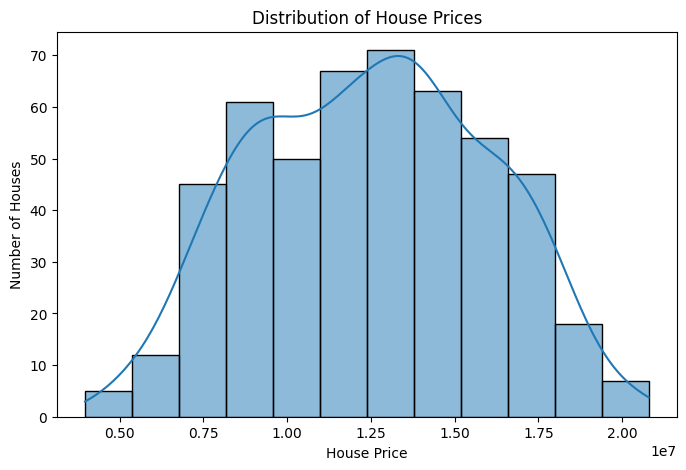

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df['SalePrice'], kde=True)

plt.title('Distribution of House Prices')
plt.xlabel('House Price')
plt.ylabel('Number of Houses')

plt.show()

### Feature Selection

The target variable is SalePrice because our goal is to predict house prices.

The important predictor features are Area, Location, Rooms, YearBuilt, Quality, GarageCars, and TotalBsmtSF.

These features are selected because house size, location, number of rooms, house age, quality, garage capacity, and basement area can affect the price of a house.

In [11]:
df['Age'] = 2026 - df['YearBuilt']

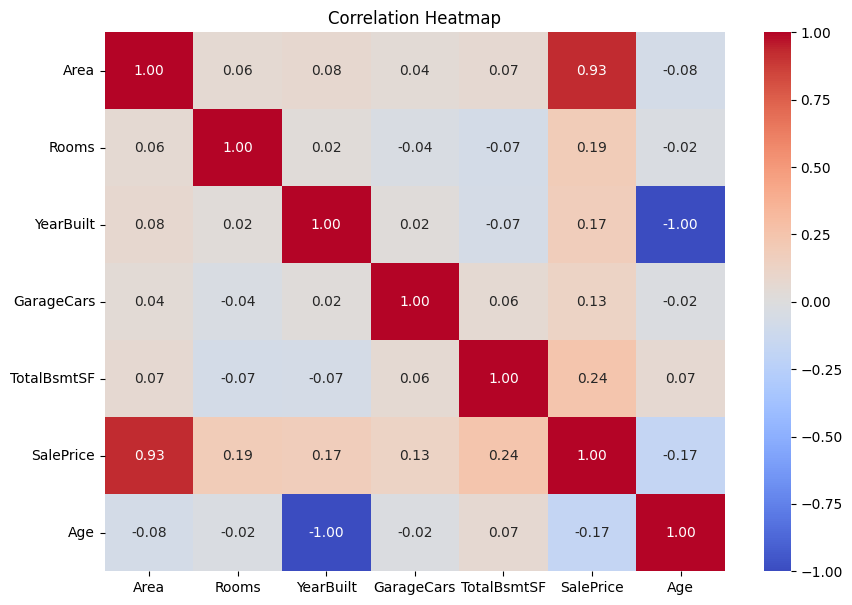

In [12]:
plt.figure(figsize=(10, 7))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [16]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (400, 8)
Testing data: (100, 8)


In [18]:
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(exclude=np.number).columns

print("Numeric Features:")
print(numeric_features.tolist())

print("\nCategorical Features:")
print(categorical_features.tolist())

Numeric Features:
['Area', 'Rooms', 'YearBuilt', 'GarageCars', 'TotalBsmtSF', 'Age']

Categorical Features:
['Location', 'Quality']


In [19]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [20]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Area', 'Rooms', 'YearBuilt', 'GarageCars', 'TotalBsmtSF', 'Age'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Location', 'Quality'], dtype='object'))])),
                ('regressor', LinearRegression())])

In [22]:
y_pred = model.predict(X_test)

print("First 10 Predicted Prices:")
print(y_pred[:10])

First 10 Predicted Prices:
[ 9049570.71650483 10472439.14603902  8741927.05607039  9532717.09427582
 17306717.2182717  15221642.69358744 15088126.4434245  18460438.58763358
 11662185.50501288 14097422.88344466]


In [24]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 290512743674.3502
Root Mean Squared Error (RMSE): 538992.3410164102
R² Score: 0.9741911112774779


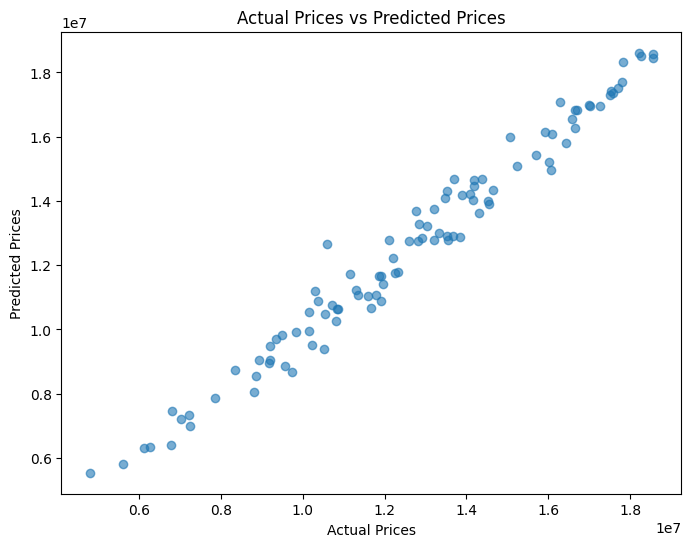

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual Prices vs Predicted Prices')

plt.show()

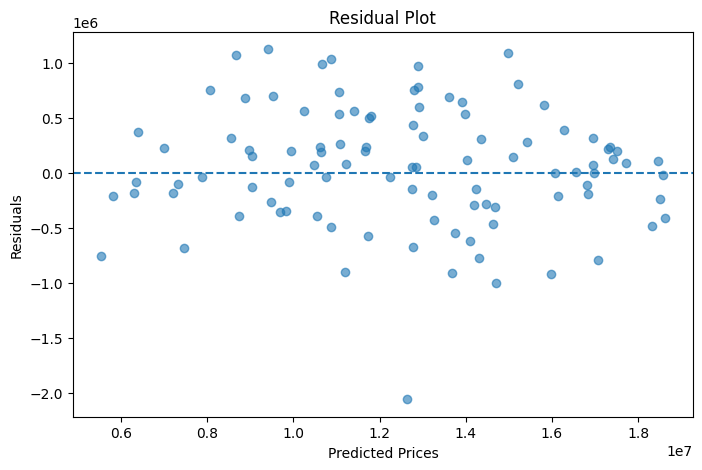

In [26]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

In [27]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coefficients = model.named_steps['regressor'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df['Absolute_Coefficient'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values(
    'Absolute_Coefficient',
    ascending=False
)

coef_df.head(10)

,Feature,Coefficient,Absolute_Coefficient
7,cat__Location_Mumbai,976011.450257,976011.450257
12,cat__Quality_Excellent,851367.774044,851367.774044
14,cat__Quality_Poor,-709544.270620,709544.270620
8,cat__Location_Nagpur,-539851.618872,539851.618872
6,cat__Location_Aurangabad,-462288.166545,462288.166545
11,cat__Quality_Average,-372400.293026,372400.293026
1,num__Rooms,345952.105648,345952.105648
3,num__GarageCars,263082.852035,263082.852035
10,cat__Location_Pune,247829.981019,247829.981019
13,cat__Quality_Good,230576.789602,230576.789602


### Conclusion

In this project, I developed a Linear Regression model to predict house prices.

I performed data cleaning, exploratory data analysis, missing value handling, and one-hot encoding of categorical features.

The dataset was divided into 80% training data and 20% testing data. The Linear Regression model was trained and evaluated using MSE, RMSE, and R² score.

I also created an Actual vs Predicted Prices plot, Residual Plot, and analysed the model coefficients.

This project helped me understand the complete machine learning workflow from data preprocessing to model training and evaluation.
